# Test-Set Evaluation of Trained Checkpoints.

Evaluate the eight trained checkpoints (four architectures x two regimes) on the
held-out test split of the patient-grouped clean corpus, and produce the metrics,
figures and tables reported in the paper.

#### Rationale:
- Read the test split exclusively from `experiments/pools_clean/`, asserting its
  size before any model is loaded, so that a superseded corpus cannot be
  evaluated silently.
- Report Wilson score confidence intervals alongside every proportion, because
  at 480 test images differences below roughly three percentage points are not
  resolvable and must not be presented as a ranking.
- Break the tuberculosis class down by radiographic activity, since it contains
  both active and healed disease and the distinction changes what the reported
  sensitivity means.
- Produce a single legible confusion-matrix figure drawn as real axes rather
  than tiled raster images.

## 1. Project Path Configuration.

Add the project root directory to Python's search path (`sys.path`) so that local
packages under `src/` (such as `dataset.py` and `transforms.py`) can be imported
from within `notebooks/`.

#### Rationale:
- Keep imports consistent across all notebooks (01_data_eda to 06_deployment_metrics).
- Enable reuse of modular code without duplication.
- Maintain reproducibility and a clean experiment structure.
- Guarantee portability across local, remote and containerised environments.

In [1]:
# Add project root to Python path so `src` can be imported.
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()   # One level up from /notebooks/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"Project root added to path: {PROJECT_ROOT}")

Project root added to path: /lab/px/AnichLabs/cxr-cnn-k8s-benchmark


## 2. Library Imports and Environment Setup.

Import the libraries required for evaluation, define the project directories, and
detect the available compute device.

#### Rationale:
- Load the core numerical, deep-learning and metric libraries in one place.
- Maintain directory structure consistency across notebooks to simplify reproducibility.
- Create missing output folders to prevent runtime errors when saving results.
- Select the available hardware automatically to ensure portability between systems.

In [2]:
import json, csv, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader

from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
)

# Directory constants, consistent with notebooks 01 to 03.
DATA_DIR        = PROJECT_ROOT / "data"
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
POOLS_DIR       = EXPERIMENTS_DIR / "pools"
SPLITS_DIR      = EXPERIMENTS_DIR / "pools_clean"
CHECKPOINTS_DIR = EXPERIMENTS_DIR / "checkpoints"
RESULTS_DIR     = EXPERIMENTS_DIR / "results"
REPORTS_DIR     = PROJECT_ROOT / "reports"
FIG_DIR         = REPORTS_DIR / "figures"
TABLE_DIR       = REPORTS_DIR / "tables"

for d in [FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Evaluation device: {DEVICE.upper()}")

Evaluation device: CUDA


## 3. Load Preprocessing Configuration.

Load `preprocessing_config.json`, generated during the data-exploration stage,
and extract the image size, class mapping and normalisation statistics for both
the ImageNet and CXR domains.

#### Rationale:
- Ensure image size, labels and normalisation match the training setup exactly.
- Maintain compatibility and reproducibility across notebooks.
- Prevent evaluation errors arising from missing or mismatched parameters.
- Fail immediately if the configuration is absent rather than part-way through evaluation.

In [3]:
cfg_path = POOLS_DIR / "preprocessing_config.json"
if not cfg_path.exists():
    raise FileNotFoundError("Missing preprocessing_config.json (run 01_data_eda.ipynb).")

cfg = json.loads(cfg_path.read_text())

IMG_SIZE       = int(cfg["img_size"])
CLASS_TO_INDEX = {k: int(v) for k, v in cfg["class_to_index"].items()}
INDEX_TO_CLASS = {v: k for k, v in CLASS_TO_INDEX.items()}
IMAGENET_MEAN  = cfg["imagenet_mean"]
IMAGENET_STD   = cfg["imagenet_std"]
CXR_MEAN       = cfg["cxr_mean"]
CXR_STD        = cfg["cxr_std"]

print("Config loaded:")
print("- IMG_SIZE:", IMG_SIZE)
print("- Classes :", CLASS_TO_INDEX)

Config loaded:
- IMG_SIZE: 256
- Classes : {'Pneumonia': 0, 'TB': 1, 'Normal': 2}


## 4. Load Fixed Test Split.

Load the held-out test split produced by `scripts/build_clean_corpus.py`. This
subset is used exclusively for testing, so that every evaluation shares the same
images and no re-splitting occurs at evaluation time.

#### Rationale:
- Read from `experiments/pools_clean/`, never from the superseded contaminated pool.
- Assert the split size before any model is constructed, so that an incorrect
  corpus is detected immediately rather than inferred later from implausible accuracy.
- Maintain proportional representation of all three classes, 160 images each.
- Confirm the presence of the `tb_activity` column required by the sub-class analysis.

In [4]:
from src.dataset import CXRThreeClassDataset
from src.transforms import build_shared_transforms

test_df = pd.read_csv(SPLITS_DIR / "test_split.csv")

print(f"Splits from: {SPLITS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Loaded test split with {len(test_df):,} images.")
print(test_df["Class"].value_counts().to_string())

# The clean corpus test split is 480 images, 160 per class.
EXPECTED_TEST = 480
if len(test_df) != EXPECTED_TEST:
    raise ValueError(
        f"Unexpected test split size: {len(test_df)}. Expected {EXPECTED_TEST} "
        "for the clean corpus. Check that experiments/pools_clean/ holds the "
        "rebuilt splits."
    )

if "tb_activity" not in test_df.columns:
    raise KeyError(
        "test_split.csv has no tb_activity column. "
        "Run scripts/annotate_tb_activity.py before evaluating."
    )

print()
print("TB activity composition of the test split:")
print(test_df.loc[test_df["Class"] == "TB", "tb_activity"]
             .value_counts().to_string())

# Ground-truth labels in split order. Every loader below uses shuffle=False, so
# predictions align row-for-row with this array and with test_df.
TEST_LABELS = test_df["Class"].map(CLASS_TO_INDEX).to_numpy()

Splits from: experiments/pools_clean
Loaded test split with 480 images.
Class
Normal       160
Pneumonia    160
TB           160

TB activity composition of the test split:
tb_activity
active        95
unlabelled    36
obsolete      26
both           3


## 5. Model Builder.

Rebuild each architecture exactly as defined in `03_model_training.ipynb`, so that
the trained weights load without shape mismatch. Models are instantiated without
pretrained weights, since the checkpoint supplies every parameter.

#### Rationale:
- Maintain architectural consistency between the training and evaluation stages.
- Prevent shape mismatches when loading trained weights from checkpoints.
- Allow evaluation of all four architectures under one uniform procedure.
- Instantiate with `weights=None`, as the initialisation regime is already
  captured in the checkpoint and must not be reintroduced here.

In [5]:
def build_model(model_name: str, num_classes: int) -> nn.Module:
    """
    Create an empty model with the structure used during training.

    Weights are not downloaded: the checkpoint supplies every parameter, and the
    training regime is recorded in the corresponding run manifest.
    """
    if model_name == "mobilenet_v2":
        m = models.mobilenet_v2(weights=None)
        m.classifier[1] = nn.Linear(m.last_channel, num_classes)
        arch_name = "MobileNetV2"
    elif model_name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=None)
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
        arch_name = "EfficientNet-B0"
    elif model_name == "resnet50":
        m = models.resnet50(weights=None)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        arch_name = "ResNet-50"
    elif model_name == "victorio":
        m = nn.Sequential(
            nn.Conv2d(3, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, num_classes),
        )
        arch_name = "Victorio CNN"
    else:
        raise ValueError(f"Unknown model: {model_name}")

    print(f"  Model built: {arch_name} ({num_classes} classes, {IMG_SIZE}px input)")
    return m

## 6. Evaluation Helpers.

Define the inference routine and the interval estimator used throughout.

Every reported proportion carries a Wilson score confidence interval. The Wilson
interval is preferred over the normal approximation here because the accuracies
lie close to 1.0 and the samples are small: the normal approximation produces
upper bounds above 1.0 in that regime, whereas the Wilson interval remains inside
the unit range and has better coverage.

#### Rationale:
- Compute per-class precision, recall and F1 in addition to macro averages, since
  per-class sensitivity is the clinically meaningful quantity in a screening task.
- Attach an interval to every proportion, so that the resolution limit of a
  480-image test set is visible in the results rather than left to the reader.
- Return predictions in split order, enabling the sub-class analysis that follows.
- Compute one-vs-rest macro AUROC for a threshold-independent view of separability.

In [6]:
def wilson_interval(successes: int, n: int, z: float = 1.96):
    """
    Wilson score interval for a binomial proportion.

    Returns (point_estimate, lower, upper). Chosen over the normal approximation
    because proportions here are close to 1.0 with small n, where the normal
    approximation can exceed the unit range.
    """
    if n == 0:
        return float("nan"), float("nan"), float("nan")
    p = successes / n
    denom  = 1 + z**2 / n
    centre = p + z**2 / (2 * n)
    spread = z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    return p, max(0.0, (centre - spread) / denom), min(1.0, (centre + spread) / denom)


def evaluate_model(model: nn.Module, loader) -> dict:
    """
    Run inference over the loader and return metrics with confidence intervals.

    The loader must be constructed with shuffle=False so that predictions align
    row-for-row with the test split DataFrame.
    """
    model.eval()
    all_logits, all_preds, all_labels = [], [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            logits = model(imgs)
            all_logits.append(logits.cpu())
            all_preds.append(logits.argmax(1).cpu())
            all_labels.append(lbls.cpu())

    logits = torch.cat(all_logits).numpy()
    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()

    # Overall accuracy with interval.
    acc, acc_lo, acc_hi = wilson_interval(int((preds == labels).sum()), len(labels))

    # Macro averages.
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )

    # Per-class metrics, in label-index order.
    n_cls = len(CLASS_TO_INDEX)
    p_c, r_c, f_c, support = precision_recall_fscore_support(
        labels, preds, average=None, zero_division=0, labels=list(range(n_cls))
    )

    per_class = {}
    for idx in range(n_cls):
        hits    = int(((preds == idx) & (labels == idx)).sum())
        n_class = int((labels == idx).sum())
        _, r_lo, r_hi = wilson_interval(hits, n_class)
        per_class[INDEX_TO_CLASS[idx]] = {
            "precision": float(p_c[idx]),
            "recall": float(r_c[idx]),
            "recall_ci": [float(r_lo), float(r_hi)],
            "f1": float(f_c[idx]),
            "support": int(support[idx]),
        }

    try:
        probs = torch.from_numpy(logits).softmax(dim=1).numpy()
        auroc = float(roc_auc_score(labels, probs, multi_class="ovr"))
    except Exception:
        auroc = float("nan")

    return {
        "accuracy": float(acc),
        "accuracy_ci": [float(acc_lo), float(acc_hi)],
        "precision": float(prec),
        "recall": float(rec),
        "f1_score": float(f1),
        "auroc": auroc,
        "per_class": per_class,
        "preds": preds,
        "labels": labels,
    }

## 7. Evaluate All Checkpoints.

Discover every `*_best.pt` checkpoint, rebuild the corresponding architecture,
apply the normalisation matching its regime, and evaluate on the test split.

The normalisation applied at test time must match the regime the model was
trained under. The checkpoint filename encodes it, and the run manifest written
by `03_model_training.ipynb` records it independently; the two are cross-checked
here so that a mismatch cannot pass unnoticed.

#### Rationale:
- Evaluate all architectures and regimes under one identical procedure.
- Rebuild the transforms per checkpoint, since ImageNet and CXR regimes require
  different normalisation statistics and applying the wrong one degrades accuracy silently.
- Verify the regime against the run manifest rather than trusting the filename alone.
- Retain predictions in split order for the sub-class analysis and confusion matrices.

In [7]:
found_ckpts = sorted(CHECKPOINTS_DIR.glob("*_best.pt"))
if not found_ckpts:
    raise FileNotFoundError("No *_best.pt checkpoints found in experiments/checkpoints/")

print("Discovered checkpoints:")
for p in found_ckpts:
    print(" -", p.name)
print()

summary, predictions = {}, {}

for ckpt_path in found_ckpts:
    name  = ckpt_path.stem                      # e.g. mobilenet_v2_imagenet_best
    parts = name.split("_")
    regime     = parts[-2]                      # imagenet | cxr
    model_name = "_".join(parts[:-2])           # mobilenet_v2 | resnet50 | ...

    # Cross-check the regime against the manifest written during training.
    manifest_path = RESULTS_DIR / f"{name}_manifest.json"
    if manifest_path.exists():
        man = json.loads(manifest_path.read_text())
        if man.get("regime") != regime:
            raise ValueError(
                f"{name}: filename regime '{regime}' disagrees with manifest "
                f"'{man.get('regime')}'."
            )
        init_note = f' | trained init: {man.get("initialisation")}'
    else:
        init_note = "  (no manifest found)"

    use_imagenet = (regime == "imagenet")
    mean = IMAGENET_MEAN if use_imagenet else CXR_MEAN
    std  = IMAGENET_STD  if use_imagenet else CXR_STD
    src  = "ImageNet" if use_imagenet else "CXR"

    _, eval_transforms = build_shared_transforms(img_size=IMG_SIZE, mean=mean, std=std)

    test_dataset = CXRThreeClassDataset(
        items=test_df,
        class_to_index=CLASS_TO_INDEX,
        transforms=eval_transforms,
        chexpert_root=DATA_DIR / "chexpert",
        tbx_root=DATA_DIR / "tbx11k",
    )
    test_loader = DataLoader(
        test_dataset, batch_size=64, shuffle=False,
        num_workers=4, pin_memory=True,
    )

    print(f"Evaluating {name} [{src}-normalised] on {len(test_dataset)} images{init_note}")

    model = build_model(model_name, num_classes=len(CLASS_TO_INDEX)).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

    metrics = evaluate_model(model, test_loader)

    # Predictions must align with the split order the sub-class analysis assumes.
    assert np.array_equal(metrics["labels"], TEST_LABELS), \
        "Label order does not match test_df. Check that the loader uses shuffle=False."

    lo, hi = metrics["accuracy_ci"]
    tb = metrics["per_class"]["TB"]
    t_lo, t_hi = tb["recall_ci"]
    print(f'  Acc={metrics["accuracy"]:.4f} [{lo:.4f}, {hi:.4f}] '
          f'F1={metrics["f1_score"]:.4f} AUROC={metrics["auroc"]:.4f}')
    print(f'  TB recall={tb["recall"]:.4f} [{t_lo:.4f}, {t_hi:.4f}] (n={tb["support"]})')
    print()

    summary[name] = {
        "model": model_name,
        "regime": regime,
        "normalisation": src,
        "accuracy": metrics["accuracy"],
        "accuracy_ci": metrics["accuracy_ci"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1_score": metrics["f1_score"],
        "auroc": metrics["auroc"],
        "per_class": metrics["per_class"],
    }
    predictions[name] = metrics["preds"]

summary_json = TABLE_DIR / "test_evaluation_summary.json"
summary_json.write_text(json.dumps(summary, indent=2))
print("Summary written to:", summary_json.relative_to(PROJECT_ROOT))

Discovered checkpoints:
 - efficientnet_b0_cxr_best.pt
 - efficientnet_b0_imagenet_best.pt
 - mobilenet_v2_cxr_best.pt
 - mobilenet_v2_imagenet_best.pt
 - resnet50_cxr_best.pt
 - resnet50_imagenet_best.pt
 - victorio_cxr_best.pt
 - victorio_imagenet_best.pt

Evaluating efficientnet_b0_cxr_best [CXR-normalised] on 480 images | trained init: random
  Model built: EfficientNet-B0 (3 classes, 256px input)
  Acc=0.9563 [0.9340, 0.9712] F1=0.9562 AUROC=0.9944
  TB recall=0.9250 [0.8735, 0.9566] (n=160)

Evaluating efficientnet_b0_imagenet_best [ImageNet-normalised] on 480 images | trained init: imagenet
  Model built: EfficientNet-B0 (3 classes, 256px input)
  Acc=0.9729 [0.9542, 0.9841] F1=0.9729 AUROC=0.9983
  TB recall=0.9437 [0.8966, 0.9701] (n=160)

Evaluating mobilenet_v2_cxr_best [CXR-normalised] on 480 images | trained init: random
  Model built: MobileNetV2 (3 classes, 256px input)
  Acc=0.9146 [0.8862, 0.9364] F1=0.9146 AUROC=0.9807
  TB recall=0.8812 [0.8220, 0.9226] (n=160)

Eval

## 8. Results Table.

Assemble the table reported in the paper.

Macro precision and recall are omitted. On a balanced three-class test set they
track accuracy to within a fraction of a percentage point, so they occupy four
columns to convey one column's information. The space is given instead to the
confidence interval and to tuberculosis recall, which is the consequential
quantity in a screening context.

#### Rationale:
- Present accuracy with its interval, so that overlapping results are visible as such.
- Report tuberculosis recall separately, since a missed tuberculosis case carries
  greater clinical cost than a missed normal study.
- Export both a CSV for the repository and a LaTeX fragment for the manuscript,
  removing the transcription step in which earlier errors were introduced.
- Order rows by accuracy while stating explicitly that the ordering is not a ranking.

In [8]:
DISPLAY_NAME = {
    "mobilenet_v2": "MobileNetV2",
    "efficientnet_b0": "EfficientNet-B0",
    "resnet50": "ResNet-50",
    "victorio": "Victorio",
}

rows = []
for name, s in summary.items():
    lo, hi = s["accuracy_ci"]
    tb = s["per_class"]["TB"]
    rows.append({
        "Model": DISPLAY_NAME[s["model"]],
        "Regime": "ImageNet" if s["regime"] == "imagenet" else "CXR",
        "Accuracy": s["accuracy"],
        "CI_low": lo,
        "CI_high": hi,
        "Macro_F1": s["f1_score"],
        "AUROC": s["auroc"],
        "TB_recall": tb["recall"],
        "TB_recall_low": tb["recall_ci"][0],
        "TB_recall_high": tb["recall_ci"][1],
    })

table = pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print(f'{"Model":18s} {"Regime":9s} {"Accuracy [95% CI]":24s} {"F1":>7s} {"AUROC":>7s} {"TB recall":>11s}')
print("-" * 84)
for _, r in table.iterrows():
    ci = f'{r["Accuracy"]:.3f} [{r["CI_low"]:.3f}, {r["CI_high"]:.3f}]'
    print(f'{r["Model"]:18s} {r["Regime"]:9s} {ci:24s} '
          f'{r["Macro_F1"]:7.3f} {r["AUROC"]:7.3f} {r["TB_recall"]:11.3f}')

csv_path = TABLE_DIR / "table1_test_results.csv"
table.to_csv(csv_path, index=False)

# LaTeX fragment, to be included rather than retyped.
lines = [
    r"\begin{tabular}{llcccc}", r"\hline",
    r"Model & Regime & Acc. [95\% CI] & Macro F1 & AUROC & TB rec. \\", r"\hline",
]
for _, r in table.iterrows():
    lines.append(
        f'{r["Model"]} & {r["Regime"]} & '
        f'{r["Accuracy"]:.3f} [{r["CI_low"]:.3f}, {r["CI_high"]:.3f}] & '
        f'{r["Macro_F1"]:.3f} & {r["AUROC"]:.3f} & {r["TB_recall"]:.3f} \\\\'
    )
lines += [r"\hline", r"\end{tabular}"]
tex_path = TABLE_DIR / "table1_test_results.tex"
tex_path.write_text("\n".join(lines))

print()
print("Saved:", csv_path.relative_to(PROJECT_ROOT))
print("Saved:", tex_path.relative_to(PROJECT_ROOT))

# Resolution limit of this test set, for the discussion.
_, w_lo, w_hi = wilson_interval(int(round(0.97 * 480)), 480)
print()
print(f"Interval half-width at p=0.97: overall {100 * (w_hi - w_lo) / 2:.2f} pp (n=480)")
_, c_lo, c_hi = wilson_interval(int(round(0.97 * 160)), 160)
print(f"Interval half-width at p=0.97: per class {100 * (c_hi - c_lo) / 2:.2f} pp (n=160)")
print("Differences below roughly 3 pp are not resolvable at this sample size.")

Model              Regime    Accuracy [95% CI]             F1   AUROC   TB recall
------------------------------------------------------------------------------------
ResNet-50          ImageNet  0.983 [0.967, 0.992]       0.983   0.999       0.988
MobileNetV2        ImageNet  0.981 [0.965, 0.990]       0.981   0.999       0.981
EfficientNet-B0    ImageNet  0.973 [0.954, 0.984]       0.973   0.998       0.944
EfficientNet-B0    CXR       0.956 [0.934, 0.971]       0.956   0.994       0.925
ResNet-50          CXR       0.954 [0.932, 0.970]       0.954   0.988       0.969
MobileNetV2        CXR       0.915 [0.886, 0.936]       0.915   0.981       0.881
Victorio           ImageNet  0.842 [0.806, 0.872]       0.839   0.933       0.694
Victorio           CXR       0.838 [0.802, 0.868]       0.836   0.935       0.706

Saved: reports/tables/table1_test_results.csv
Saved: reports/tables/table1_test_results.tex

Interval half-width at p=0.97: overall 1.55 pp (n=480)
Interval half-width at p=0.9

## 9. Tuberculosis Activity Sub-Recall.

Report recall separately for active and healed tuberculosis.

TBX11K annotates three tuberculosis categories, of which ActiveTuberculosis and
ObsoletePulmonaryTuberculosis are clinically distinct: obsolete disease is healed
scarring from a resolved infection, not active infectious disease. The tuberculosis
images drawn from Montgomery, Shenzhen, DA and DB carry a positive label with no
activity sub-classification at all.

The consequence is that reported tuberculosis recall is sensitivity to
tuberculosis-associated radiographic findings, not to active infection, and the
paper must say so.

#### Rationale:
- Quantify whether performance differs between active and healed disease, which
  the aggregate tuberculosis recall conceals.
- Disclose that a quarter of the tuberculosis class has unknown activity, a
  property of the source datasets that cannot be resolved.
- Attach intervals, since the 26 obsolete test cases support only an indicative estimate.
- Export the breakdown for reference without promoting it to a table in the paper.

In [9]:
tb_index = CLASS_TO_INDEX["TB"]
tb_mask  = (test_df["Class"] == "TB").to_numpy()
activity = test_df["tb_activity"].to_numpy()

GROUPS = ["active", "obsolete", "unlabelled"]   # 'both' has n=3, reported in CSV only

print("TB test-set composition:")
for label, n in pd.Series(activity[tb_mask]).value_counts().items():
    print(f"  {label:12s} {n:3d}")
print()

header = f'{"Model":32s} | ' + " | ".join(g.rjust(18) for g in GROUPS)
print(header)
print("-" * len(header))

sub_rows = []
for name in sorted(predictions):
    preds = predictions[name]
    cells = []
    for group in GROUPS + ["both"]:
        sel   = tb_mask & (activity == group)
        n_sel = int(sel.sum())
        if n_sel == 0:
            if group in GROUPS:
                cells.append("-".rjust(18))
            continue
        hits = int((preds[sel] == tb_index).sum())
        r, lo, hi = wilson_interval(hits, n_sel)
        if group in GROUPS:
            cells.append(f"{r:.3f} [{lo:.2f},{hi:.2f}]".rjust(18))
        sub_rows.append({
            "model": name, "subclass": group, "n": n_sel, "correct": hits,
            "recall": round(r, 4), "ci_low": round(lo, 4), "ci_high": round(hi, 4),
        })
    print(f'{name:32s} | ' + " | ".join(cells))

sub_csv = TABLE_DIR / "tb_activity_recall.csv"
pd.DataFrame(sub_rows).to_csv(sub_csv, index=False)
print()
print("Saved:", sub_csv.relative_to(PROJECT_ROOT))
print()
print("Note: the 26 obsolete cases give an interval roughly 9 to 19 pp wide "
      "depending on the value, so these figures are indicative rather than "
      "conclusive. The 3 images annotated both active and obsolete are recorded "
      "in the CSV but are too few to interpret.")

TB test-set composition:
  active        95
  unlabelled    36
  obsolete      26
  both           3

Model                            |             active |           obsolete |         unlabelled
-----------------------------------------------------------------------------------------------
efficientnet_b0_cxr_best         |  0.916 [0.84,0.96] |  0.923 [0.76,0.98] |  0.944 [0.82,0.98]
efficientnet_b0_imagenet_best    |  0.958 [0.90,0.98] |  0.962 [0.81,0.99] |  0.889 [0.75,0.96]
mobilenet_v2_cxr_best            |  0.874 [0.79,0.93] |  0.885 [0.71,0.96] |  0.917 [0.78,0.97]
mobilenet_v2_imagenet_best       |  0.979 [0.93,0.99] |  1.000 [0.87,1.00] |  0.972 [0.86,1.00]
resnet50_cxr_best                |  0.968 [0.91,0.99] |  0.962 [0.81,0.99] |  0.972 [0.86,1.00]
resnet50_imagenet_best           |  0.979 [0.93,0.99] |  1.000 [0.87,1.00] |  1.000 [0.90,1.00]
victorio_cxr_best                |  0.705 [0.61,0.79] |  0.577 [0.39,0.74] |  0.806 [0.65,0.90]
victorio_imagenet_best           |

## 10. Test Accuracy Comparison.

Plot test accuracy for all eight checkpoints with confidence intervals.

#### Rationale:
- Show the ImageNet and CXR regimes side by side for each architecture.
- Draw the interval on every bar, so that overlapping results are visually
  apparent and cannot be read as a ranking.
- Group by architecture, matching the structure of the discussion.
- Export at publication resolution for direct inclusion in the manuscript.

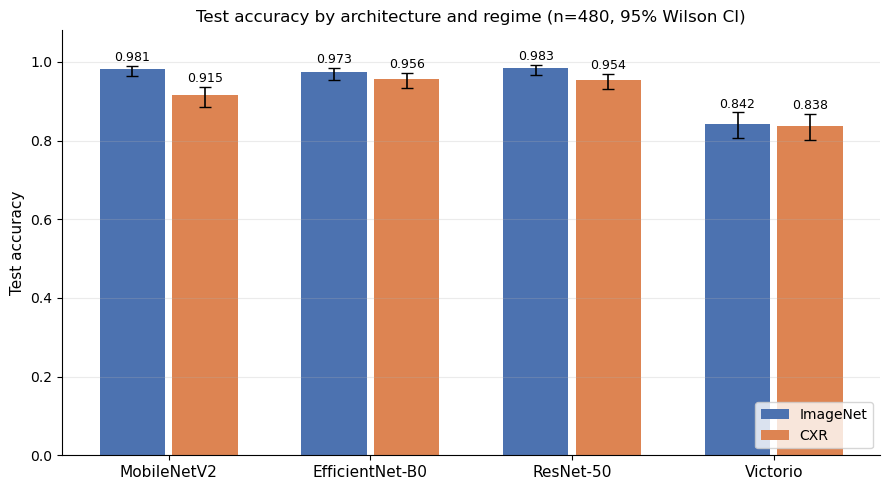

Saved: reports/figures/test_accuracy_all_models.png


In [10]:
ORDER = ["mobilenet_v2", "efficientnet_b0", "resnet50", "victorio"]

fig, ax = plt.subplots(figsize=(9, 5))
width, xs, labels = 0.36, [], []

for i, arch in enumerate(ORDER):
    for j, regime in enumerate(["imagenet", "cxr"]):
        key = f"{arch}_{regime}_best"
        if key not in summary:
            continue
        s = summary[key]
        lo, hi = s["accuracy_ci"]
        x = i + (j - 0.5) * width
        ax.bar(x, s["accuracy"], width * 0.9,
               color="#4C72B0" if regime == "imagenet" else "#DD8452",
               label=("ImageNet" if regime == "imagenet" else "CXR") if i == 0 else None)
        ax.errorbar(x, s["accuracy"],
                    yerr=[[s["accuracy"] - lo], [hi - s["accuracy"]]],
                    fmt="none", ecolor="black", capsize=4, lw=1.2)
        ax.text(x, hi + 0.012, f'{s["accuracy"]:.3f}', ha="center", fontsize=9)
        xs.append(x)

ax.set_xticks(range(len(ORDER)))
ax.set_xticklabels([DISPLAY_NAME[a] for a in ORDER], fontsize=11)
ax.set_ylabel("Test accuracy", fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_title("Test accuracy by architecture and regime (n=480, 95% Wilson CI)",
             fontsize=12)
ax.legend(fontsize=10, loc="lower right", frameon=True)
ax.grid(axis="y", alpha=0.25)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

plt.tight_layout()
out = FIG_DIR / "test_accuracy_all_models.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out.relative_to(PROJECT_ROOT))

## 11. Confusion Matrices.

Draw all eight confusion matrices as a single figure.

The previous implementation saved eight separate images and then reloaded and
tiled them into a grid, so every panel was resampled twice and the default label
sizes became unreadable at print scale. This version draws each panel as a real
set of axes with explicit font sizes, which resolves the legibility problem
raised in review.

#### Rationale:
- Produce one vector-consistent figure rather than a mosaic of raster images.
- Annotate every cell with its count, since the counts are what a reader needs.
- Arrange ImageNet above CXR so that the regime comparison reads down each column.
- Size the labels for the printed page rather than for the notebook display.

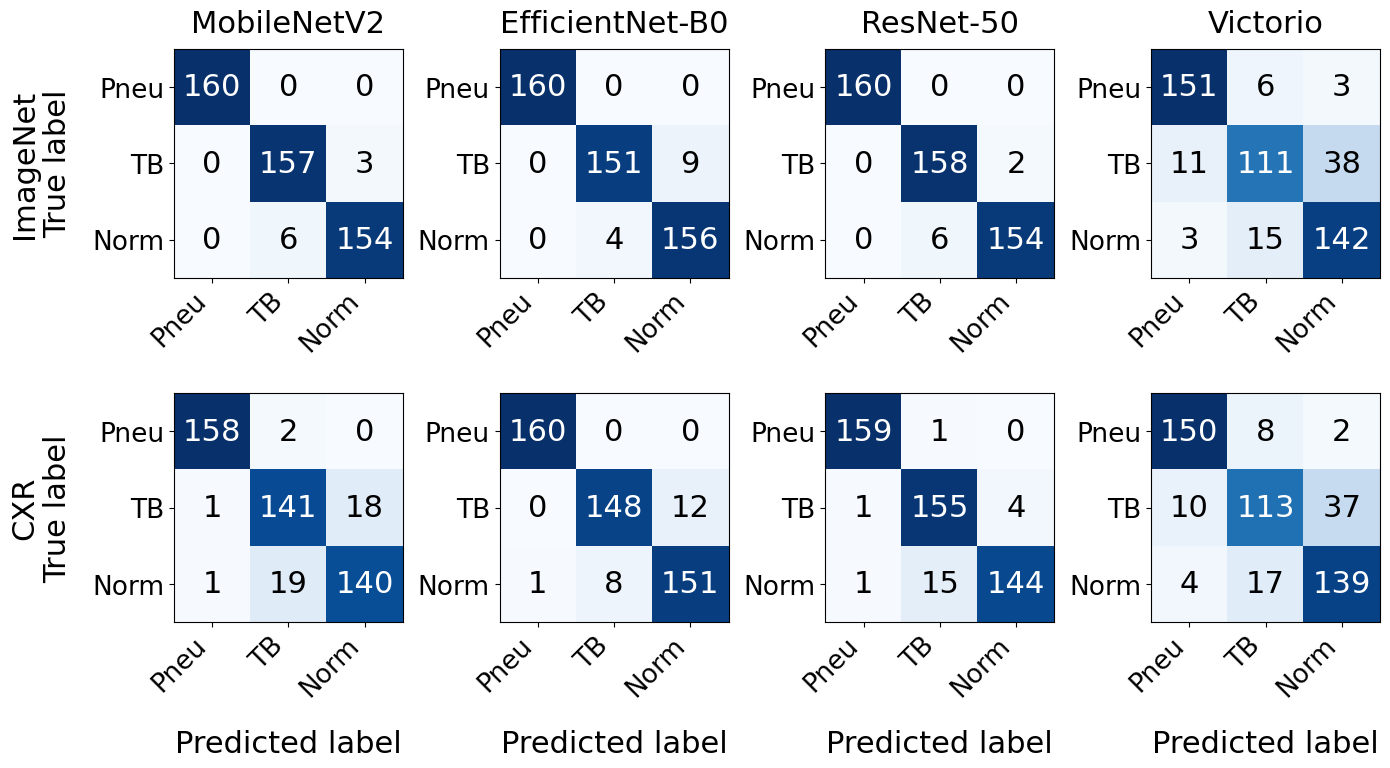

Saved: reports/figures/confusion_matrices_grid.png


In [30]:
class_names = [INDEX_TO_CLASS[i] for i in range(len(CLASS_TO_INDEX))]
short_names = ["Pneu", "TB", "Norm"]

fig, axes = plt.subplots(2, 4, figsize=(14, 8))
for col, arch in enumerate(ORDER):
    for row, regime in enumerate(["imagenet", "cxr"]):
        ax  = axes[row, col]
        key = f"{arch}_{regime}_best"
        if key not in predictions:
            ax.axis("off")
            continue
        cm = confusion_matrix(TEST_LABELS, predictions[key],
                              labels=list(range(len(class_names))))
        ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, f"{cm[i, j]:d}", ha="center", va="center",
                        fontsize=22,
                        color="white" if cm[i, j] > cm.max() * 0.5 else "black")
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(short_names, fontsize=19, rotation=45, ha="right")
        ax.set_yticklabels(short_names, fontsize=19)
        if row == 0:
            ax.set_title(DISPLAY_NAME[arch], fontsize=22, pad=12)
        if col == 0:
            ax.set_ylabel(f'{"ImageNet" if regime == "imagenet" else "CXR"}\nTrue label',
                          fontsize=22, labelpad=14)
        if row == 1:
            ax.set_xlabel("Predicted label", fontsize=22, labelpad=20)
plt.tight_layout()
out = FIG_DIR / "confusion_matrices_grid.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out.relative_to(PROJECT_ROOT))
# Remove superseded single-model figures so that stale panels cannot be reused.
stale = list(FIG_DIR.glob("*_confusion_matrix.png"))
for p in stale:
    p.unlink()
if stale:
    print(f"Removed {len(stale)} superseded single-model confusion matrices.")

## 12. Per-Class Metrics.

Full per-class precision, recall and F1 for every checkpoint, exported for the
appendix and for the repository record.

#### Rationale:
- Provide the per-class detail that the main table omits for space.
- Attach recall intervals, since per-class figures rest on 160 images each.
- Export in a form that can be included directly rather than retyped.
- Keep the record complete even where the paper reports only a summary.

In [12]:
per_class_rows = []
for name, s in sorted(summary.items()):
    for cls, m in s["per_class"].items():
        per_class_rows.append({
            "model": name,
            "class": cls,
            "support": m["support"],
            "precision": round(m["precision"], 4),
            "recall": round(m["recall"], 4),
            "recall_ci_low": round(m["recall_ci"][0], 4),
            "recall_ci_high": round(m["recall_ci"][1], 4),
            "f1": round(m["f1"], 4),
        })

per_class_df = pd.DataFrame(per_class_rows)
pc_path = TABLE_DIR / "per_class_metrics.csv"
per_class_df.to_csv(pc_path, index=False)

print(per_class_df.to_string(index=False))
print()
print("Saved:", pc_path.relative_to(PROJECT_ROOT))

                        model     class  support  precision  recall  recall_ci_low  recall_ci_high     f1
     efficientnet_b0_cxr_best Pneumonia      160     0.9938  1.0000         0.9766          1.0000 0.9969
     efficientnet_b0_cxr_best        TB      160     0.9487  0.9250         0.8735          0.9566 0.9367
     efficientnet_b0_cxr_best    Normal      160     0.9264  0.9437         0.8966          0.9701 0.9350
efficientnet_b0_imagenet_best Pneumonia      160     1.0000  1.0000         0.9766          1.0000 1.0000
efficientnet_b0_imagenet_best        TB      160     0.9742  0.9437         0.8966          0.9701 0.9587
efficientnet_b0_imagenet_best    Normal      160     0.9455  0.9750         0.9375          0.9902 0.9600
        mobilenet_v2_cxr_best Pneumonia      160     0.9875  0.9875         0.9556          0.9966 0.9875
        mobilenet_v2_cxr_best        TB      160     0.8704  0.8812         0.8220          0.9226 0.8758
        mobilenet_v2_cxr_best    Normal      1

## Appendix: Reading These Results.

**Resolution limit.** With 480 test images the 95 per cent Wilson interval on
overall accuracy is roughly one and a half percentage points either side; per
class, on 160 images, roughly two and a half. Differences below about three
percentage points between models are therefore not resolvable, and the ordering
of the results table is not a ranking.

**Regime asymmetry for the custom architecture.** No ImageNet weights exist for
Victorio, so both of its runs begin from random initialisation and differ only in
normalisation statistics. Its two rows compare normalisation, whereas the rows
for the three backbones compare pretraining against training from scratch. The
run manifests record the initialisation actually used for each checkpoint.

**Source confound.** Pneumonia is drawn entirely from CheXpert, while Normal and
Tuberculosis contain none. Part of the reported separability is therefore
attributable to acquisition source rather than to pathology, and the figures
should be read as an upper bound on clinical performance. A source-discriminating
classifier is required to quantify the effect.

**Tuberculosis class definition.** The class comprises radiographs with any
tuberculosis annotation: 58.8 per cent active, 13.0 per cent obsolete, 2.8 per
cent both, and 25.5 per cent of unknown activity. Reported tuberculosis recall is
sensitivity to tuberculosis-associated findings, not to active infection.